# A genuine `direction_id` conflict -- synthetic `direction_issue` feed

`Shapes.assign_direction_ids` (see `pyGTFSHandler/models/shapes.py`)
reconciles per-stop geometric direction clustering into one consistent
`direction_id` (0/1) per `shape_id` across a whole route, flagging
`direction_id_issues` wherever that isn't possible. This notebook builds
the smallest feed that actually forces such a conflict.

**Why 2 trips are never enough.** With only 2 shapes on a route, a
conflict is mathematically impossible: at any stop where both are
present, splitting them into 2 local groups always puts them in
*different* bins (2 points always define 2 gaps whose midpoints are 180
degrees apart -- an unavoidable property of the widest-gap split, not a
geometry-specific quirk). So every stop only ever contributes the same
kind of statement -- "these two differ" -- and reconciling that is
trivial (equivalent to 2-colouring a graph with a single edge). A real,
unresolvable conflict needs an **odd cycle** in that reconciliation graph,
which needs at least 3 shapes.

**The four shapes here.** Two "original" trips, plus the exact reverse of
each:

| trip | stops | shape |
|------|-------|-------|
| T1 | S1 -> S2 -> S3 -> S4 -> S5 -> S6 -> S7 | straight line east |
| T2 | S1 -> S2 -> S8 -> S9 -> S7 -> S6 | shares S1/S2 with T1, detours north via S8/S9, re-enters the line at S7, then **backtracks** to S6 |
| T3 | S7 -> S6 -> S5 -> S4 -> S3 -> S2 -> S1 | exact reverse of T1 |
| T4 | S6 -> S7 -> S9 -> S8 -> S2 -> S1 | exact reverse of T2 |

All four are on the same `route_id` (`R1`), all frequency-based
(`frequencies.txt`, 07:00-09:00, 10 min headway each).

T2's backtrack over the S6<->S7 segment is the crux: T2 traverses that
segment in the *opposite* order to T1. At S1/S2 (both trips heading the
same way) and at S6 (where T2 terminates, having just arrived from S7),
T2/T4's local bearings pull against T1/T3's, and with all four shapes
present to corroborate each other, that pull can no longer be waved away
by a single per-stop flip -- it's a genuine conflict.

In [1]:
import datetime
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from pyGTFSHandler import Feed

for candidate in (Path.cwd() / "test_files" / "direction_issue", Path.cwd() / "examples" / "test_files" / "direction_issue"):
    if candidate.is_dir():
        DATA_DIR = candidate
        break
else:
    raise FileNotFoundError(
        "Could not find test_files/direction_issue relative to the current working "
        f"directory ({Path.cwd()}) -- run this notebook from the repo root or from examples/"
    )

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    feed = Feed(DATA_DIR)
    direction_id_warnings = [w for w in caught if "direction_id assignment" in str(w.message)]

service_date = datetime.date(2026, 8, 3)
start_time = datetime.time(7, 0)
end_time = datetime.time(9, 0)

print(f"{len(direction_id_warnings)} direction_id warning(s) raised during Feed construction:")
for w in direction_id_warnings:
    print(f"  {w.message}")

1 direction_id warning(s) raised during Feed construction:
  direction_id assignment: 2 of 4 shape_ids (50.0%) had unresolved direction conflicts (both direction_id values in their own stop sequence), across 3 of 9 stop(s) (33.3%).


## 1. The raw network

S1-S7 lie on a straight east-west line; S8/S9 are a one-unit-north detour
used only by T2/T4. Arrows show each trip's direction of travel.

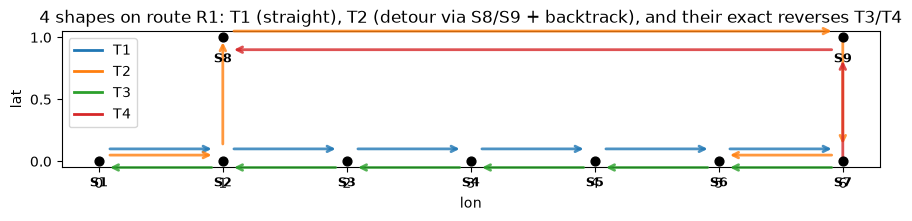

In [2]:
stops_gdf = feed.stops.gdf.copy()
stops_gdf["lon"] = stops_gdf.geometry.x
stops_gdf["lat"] = stops_gdf.geometry.y
stop_coords = dict(zip(stops_gdf["stop_id"], zip(stops_gdf["lon"], stops_gdf["lat"])))

stop_times_df = feed.stop_times.lf.sort(["trip_id", "stop_sequence"]).collect()

trip_colors = {"T1": "tab:blue", "T2": "tab:orange", "T3": "tab:green", "T4": "tab:red"}
# Small per-trip vertical offset so overlapping segments (e.g. all 4 trips
# share S1->S2) are still visible as separate lines.
trip_offsets = {"T1": 0.10, "T2": 0.05, "T3": -0.05, "T4": -0.10}

fig, ax = plt.subplots(figsize=(9, 5))

for trip_id, group in stop_times_df.group_by("trip_id", maintain_order=True):
    trip_id = trip_id[0]
    base_name = trip_id.split("_file_")[0]
    xs = [stop_coords[s][0] for s in group["stop_id"]]
    ys = [stop_coords[s][1] + trip_offsets[base_name] for s in group["stop_id"]]
    color = trip_colors[base_name]
    for i in range(len(xs) - 1):
        ax.annotate(
            "",
            xy=(xs[i + 1], ys[i + 1]),
            xytext=(xs[i], ys[i]),
            arrowprops=dict(arrowstyle="->", color=color, lw=2, alpha=0.8,
                             shrinkA=8, shrinkB=8),
        )
    ax.plot([], [], color=color, lw=2, label=base_name)

for stop_id, (lon, lat) in stop_coords.items():
    ax.scatter([lon], [lat], color="black", s=40, zorder=5)
    ax.annotate(
        stop_id.split("_file_")[0], (lon, lat),
        textcoords="offset points", xytext=(0, -18), fontsize=9, fontweight="bold", ha="center",
    )

ax.set_title("4 shapes on route R1: T1 (straight), T2 (detour via S8/S9 + backtrack), and their exact reverses T3/T4")
ax.set_xlabel("lon")
ax.set_ylabel("lat")
ax.legend(loc="upper left")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 2. `feed.shapes.stop_shapes`: the reconciled result

`direction_id`/`direction_id_issues` are integrated directly into
`stop_shapes`, alongside the untouched raw `shape_direction`/
`shape_direction_backwards` bearings.

In [3]:
stop_shapes_df = (
    feed.shapes.stop_shapes.select(
        [
            "route_id", "shape_id", "stop_id", "stop_sequence",
            "shape_direction", "shape_direction_backwards",
            "direction_id", "direction_id_issues",
        ]
    )
    .collect()
    .sort(["stop_id", "shape_id"])
)
with pl.Config(tbl_rows=-1):
    print(stop_shapes_df)

shape: (26, 8)
┌───────────┬───────────┬───────────┬────────────┬────────────┬────────────┬───────────┬───────────┐
│ route_id  ┆ shape_id  ┆ stop_id   ┆ stop_seque ┆ shape_dire ┆ shape_dire ┆ direction ┆ direction │
│ ---       ┆ ---       ┆ ---       ┆ nce        ┆ ction      ┆ ction_back ┆ _id       ┆ _id_issue │
│ str       ┆ str       ┆ str       ┆ ---        ┆ ---        ┆ wards      ┆ ---       ┆ s         │
│           ┆           ┆           ┆ i64        ┆ f64        ┆ ---        ┆ i32       ┆ ---       │
│           ┆           ┆           ┆            ┆            ┆ f64        ┆           ┆ bool      │
╞═══════════╪═══════════╪═══════════╪════════════╪════════════╪════════════╪═══════════╪═══════════╡
│ R1_file_0 ┆ T1_file_0 ┆ S1_file_0 ┆ 0          ┆ 90.0       ┆ NaN        ┆ 1         ┆ false     │
│ R1_file_0 ┆ T2_file_0 ┆ S1_file_0 ┆ 0          ┆ 83.986522  ┆ NaN        ┆ 1         ┆ true      │
│ R1_file_0 ┆ T3_file_0 ┆ S1_file_0 ┆ 6          ┆ NaN        ┆ 90.0       ┆

T1 and T3 (the straight line and its exact reverse) get a clean,
consistent `direction_id` at every stop, `direction_id_issues` always
`False`. T2 and T4 (the detouring pair) get `direction_id_issues=True` at
S1, S2, and S6 -- exactly where their own local bearings pull against
T1/T3's established pairing:

In [4]:
flagged = stop_shapes_df.filter(pl.col("direction_id_issues"))
print(flagged.select(["shape_id", "stop_id", "direction_id"]))

flagged_shape_ids = sorted(s.split("_file_")[0] for s in flagged["shape_id"].unique().to_list())
flagged_stop_ids = sorted(s.split("_file_")[0] for s in flagged["stop_id"].unique().to_list())
print(f"\nFlagged shapes: {flagged_shape_ids}")
print(f"Flagged stops:  {flagged_stop_ids}")

shape: (6, 3)
┌───────────┬───────────┬──────────────┐
│ shape_id  ┆ stop_id   ┆ direction_id │
│ ---       ┆ ---       ┆ ---          │
│ str       ┆ str       ┆ i32          │
╞═══════════╪═══════════╪══════════════╡
│ T2_file_0 ┆ S1_file_0 ┆ 1            │
│ T4_file_0 ┆ S1_file_0 ┆ 0            │
│ T2_file_0 ┆ S2_file_0 ┆ 1            │
│ T4_file_0 ┆ S2_file_0 ┆ 0            │
│ T2_file_0 ┆ S6_file_0 ┆ 1            │
│ T4_file_0 ┆ S6_file_0 ┆ 0            │
└───────────┴───────────┴──────────────┘

Flagged shapes: ['T2', 'T4']
Flagged stops:  ['S1', 'S2', 'S6']


## 3. Plotting the conflict

Each stop shows one arrow per shape, along its raw bearing, coloured by
the *resolved* `direction_id` (blue = 0, orange = 1). Flagged
`(shape_id, stop_id)` rows are outlined in red -- these are the specific
rows where a shape's own established direction lost to the majority at
that one stop.

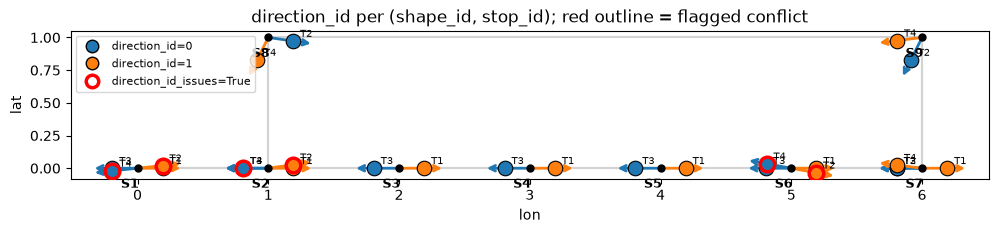

In [5]:
OFFSET_DEG = 0.35
direction_colors = {0: "tab:blue", 1: "tab:orange"}

fig, ax = plt.subplots(figsize=(10, 6))

# Faint underlay of the raw trip paths for context.
for trip_id, group in stop_times_df.group_by("trip_id", maintain_order=True):
    xs = [stop_coords[s][0] for s in group["stop_id"]]
    ys = [stop_coords[s][1] for s in group["stop_id"]]
    ax.plot(xs, ys, "-", color="lightgray", linewidth=1.5, zorder=1)

for row in stop_shapes_df.iter_rows(named=True):
    lon, lat = stop_coords[row["stop_id"]]
    bearing = row["shape_direction"]
    if bearing is None or bearing != bearing:  # None or NaN (terminal stop)
        bearing = (row["shape_direction_backwards"] + 180) % 360
    bearing_rad = np.deg2rad(bearing)
    dx = np.sin(bearing_rad) * OFFSET_DEG
    dy = np.cos(bearing_rad) * OFFSET_DEG

    color = direction_colors[row["direction_id"]]
    edge_color = "red" if row["direction_id_issues"] else "black"
    edge_width = 2.5 if row["direction_id_issues"] else 0.8

    ax.annotate(
        "",
        xy=(lon + dx, lat + dy),
        xytext=(lon, lat),
        arrowprops=dict(arrowstyle="->", color=color, lw=2),
        zorder=2,
    )
    ax.scatter([lon + dx * 0.55], [lat + dy * 0.55], color=color, s=110,
               edgecolor=edge_color, linewidth=edge_width, zorder=3)
    ax.annotate(
        row["shape_id"].split("_file_")[0],
        (lon + dx * 0.55, lat + dy * 0.55),
        textcoords="offset points", xytext=(5, 3), fontsize=7,
    )

for stop_id, (lon, lat) in stop_coords.items():
    ax.scatter([lon], [lat], color="black", s=25, zorder=4)
    ax.annotate(
        stop_id.split("_file_")[0], (lon, lat),
        textcoords="offset points", xytext=(-12, -14), fontsize=9, fontweight="bold",
    )

handles = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=c, markeredgecolor="black", markersize=9, label=f"direction_id={d}")
    for d, c in direction_colors.items()
]
handles.append(
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="white", markeredgecolor="red", markeredgewidth=2.5,
               markersize=9, label="direction_id_issues=True")
)
ax.legend(handles=handles, loc="upper left", fontsize=8)
ax.set_title("direction_id per (shape_id, stop_id); red outline = flagged conflict")
ax.set_xlabel("lon")
ax.set_ylabel("lat")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## Takeaways

- T1 and T3 are exact reverses of a simple straight line -- they never
  conflict, at any stop.
- T2 backtracks over the S6<->S7 segment relative to T1's direction of
  travel there. With only T1 and T2 present, this is *never* flagged (2
  shapes can always be reconciled by a single per-stop flip -- see the
  intro). Adding T2's own reverse, T4, is what supplies the 3rd
  (effectively 4th) shape needed to create an actual contradiction: T1/T3
  anchor one pairing at S1/S2/S6, and T2/T4's local bearings there can't
  be reconciled with it, so their rows at those three stops are forced to
  the majority and flagged.
- The feed-wide warning summarises this precisely: 2 of 4 shape_ids
  (50.0%) affected, across 3 of 9 stops (33.3%).